In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import optuna



In [2]:
# ---------------------------
# 1) SETUP AND SEED
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
os.environ["CC"] = "/usr/bin/gcc"
torch.set_float32_matmul_precision('high')
optuna.logging.set_verbosity(optuna.logging.INFO)

In [3]:
# ---------------------------
# 2) LOAD ORIGINAL DATA
# ---------------------------

train_df = pd.read_csv('../../../data/train_resample_minmax_all.csv')
test_df = pd.read_csv('../../../data/test_resample_minmax_all.csv')
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Extraire les identifiants
train_ids = set(train_df["apogee_id"].tolist())
test_ids  = set(test_df["apogee_id"].tolist())


original_data = pd.concat([train_df, test_df])

# Keep a copy of apogee_id
apogee_ids = original_data["apogee_id"].copy()

# Keep the 17 abundance columns, dropping ID and any extra columns
columns_to_drop = ["apogee_id", "TEFF", "J", "H", "K", "LOGG"]
abundance_data = original_data.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)



col_names = [
    "C_FE", "CI_FE", "N_FE", "O_FE", "NA_FE", "MG_FE", "AL_FE",
    "SI_FE", "S_FE", "K_FE", "CA_FE", "TI_FE", "V_FE", "CR_FE",
    "MN_FE", "NI_FE", "FE_H"
]

abundance_full = original_data[["apogee_id"] + col_names].copy()
abundance_full[col_names] = abundance_full[col_names].astype('float32')

print("Original abundance data shape:", abundance_data.shape)

Train shape: (129124, 23)
Test shape: (32282, 23)
Original abundance data shape: (161406, 17)


In [4]:
class InverseProjectionDataset(Dataset):
    def __init__(self, x_latent, y_target):
        """
        x_latent: numpy array [N, latent_dim] des projections (latent space)
        y_target: numpy array [N, 17] des abundances originales, avec colonnes selon col_names
        """
        self.x_latent = torch.tensor(x_latent, dtype=torch.float32)
        self.y_target = torch.tensor(y_target, dtype=torch.float32)
        self.n = self.x_latent.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x_latent[idx], self.y_target[idx]
class InverseProjectionNet(nn.Module):
    """
    A feed-forward network to reconstruct 17D abundances from an N-D embedding.
    Architecture: N -> 64 -> 32 -> 17, with BatchNorm and LeakyReLU.
    """
    def __init__(self, input_dim=2, output_dim=17):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        return self.fc3(x)


In [5]:
class InverseProjectionNetOpt(nn.Module):
    def __init__(self, input_dim=2, output_dim=17, hidden_dims=[64, 32], negative_slope=0.01):
        """
        input_dim: dimension du latent space (ex. 2,3,4)
        output_dim: 17 (les 17 abondances)
        hidden_dims: liste des dimensions cachées (la longueur de la liste définit le nombre de couches cachées)
        negative_slope: paramètre pour le LeakyReLU
        """
        super(InverseProjectionNetOpt, self).__init__()
        layers = []
        current_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(current_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.LeakyReLU(negative_slope=negative_slope))
            current_dim = h
        layers.append(nn.Linear(current_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Exemple de liste de projections à tester
projection_latent_dfs = [
    ("autoencoder_latent_space_2D", pd.read_csv("output_dataset/autoencoder_latent_space_2D.csv"), 2),
    ("CosineKPCA_latent_space_2D", pd.read_csv("output_dataset/CosineKPCA_latent_space_2D.csv"), 2),
    ("PCA_latent_space_2D", pd.read_csv("output_dataset/PCA_latent_space_2D.csv"), 2),
    ("siamese_multitask_model_triplet_2D", pd.read_csv("output_dataset/siamese_multitask_model_triplet_2D.csv"), 2),
    ("tempLoggRegressor_latent_space_2D", pd.read_csv("output_dataset/tempLoggRegressor_latent_space_2D.csv"), 2),
    ("tsne_embedding_2D", pd.read_csv("output_dataset/tsne_embedding_2D.csv"), 2),
    ("umap_embedding_2D", pd.read_csv("output_dataset/umap_embedding_2D.csv"), 2),
    ("VAE_latent_space_2D", pd.read_csv("output_dataset/VAE_latent_space_2D.csv"), 2),

]


def objective_inverse_multi(trial):
    # --- Hyperparamètres à tuner ---
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_dims = []
    for i in range(n_layers):
        h = trial.suggest_int(f"hidden_dim_{i+1}", 16, 128, step=16)
        hidden_dims.append(h)
    negative_slope = trial.suggest_float("negative_slope", 1e-3, 1e-1, log=True)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    # Cette fonction va entraîner un modèle inverse pour chaque projection dans projection_latent_dfs
    # et renvoyer la loss moyenne de validation.
    val_losses = []

    for (method_name, latent_df, input_dim) in projection_latent_dfs:
        print(f"Evaluating method: {method_name}")
        # Fusionner latent_df avec abundance_full sur "apogee_id"
        merged = pd.merge(latent_df, abundance_full, on="apogee_id", how="inner")
        if merged.empty:
            print(f"Warning: Merged dataframe for {method_name} is empty. Skipping.")
            continue

        # Séparer en train et test en fonction des apogee_id
        train_merged = merged[merged["apogee_id"].isin(train_ids)].reset_index(drop=True)
        test_merged  = merged[merged["apogee_id"].isin(test_ids)].reset_index(drop=True)

        latent_cols = [c for c in latent_df.columns if c != "apogee_id"]
        X_latent_train = train_merged[latent_cols].values.astype(np.float32)
        X_latent_test  = test_merged[latent_cols].values.astype(np.float32)
        Y_train = train_merged[col_names].values.astype(np.float32)
        Y_test  = test_merged[col_names].values.astype(np.float32)

        # Création des datasets et loaders
        train_dataset = InverseProjectionDataset(X_latent_train, Y_train)
        test_dataset  = InverseProjectionDataset(X_latent_test, Y_test)
        train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
        test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False)

        # Créer le modèle inverse flexible avec InverseProjectionNetOpt
        model = InverseProjectionNetOpt(input_dim=input_dim, output_dim=17,
                                        hidden_dims=hidden_dims,
                                        negative_slope=negative_slope).to(device)
        model = torch.compile(model, mode="reduce-overhead")
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        num_epochs = 30  # nombre réduit pour accélérer l'évaluation
        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            total_samples = 0
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * x_batch.size(0)
                total_samples += x_batch.size(0)

                print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/total_samples:.3f}")

            # On ne fait pas d'early stopping ici, pour simplifier
        # Validation
        model.eval()
        running_val_loss = 0.0
        total_val = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item() * x_batch.size(0)
                total_val += x_batch.size(0)
        val_loss = running_val_loss / total_val if total_val > 0 else float("inf")
        print(f"Method {method_name}: Val Loss = {val_loss:.6f}")
        val_losses.append(val_loss)

    aggregated_loss = np.mean(val_losses)
    trial.report(aggregated_loss, 0)
    return aggregated_loss

# Exemple d'exécution
study_inverse_multi = optuna.create_study(direction="minimize")
study_inverse_multi.optimize(objective_inverse_multi, n_trials=10, show_progress_bar=True)

print("Best trial:")
best_trial = study_inverse_multi.best_trial
print(f"  Value: {best_trial.value}")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")


[I 2025-03-29 12:12:13,326] A new study created in memory with name: no-name-bc0a8312-dc26-4158-bdbc-d273dd94ec3e


  0%|          | 0/10 [00:00<?, ?it/s]

Evaluating method: autoencoder_latent_space_2D


Traceback (most recent call last):
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/_inductor/compile_worker/__main__.py", line 7, in <module>
    from torch._inductor.async_compile import pre_fork_setup
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/_inductor/async_compile.py", line 14, in <module>
    from torch._dynamo.device_interface import get_registered_device_interfaces
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/_dynamo/__init__.py", line 3, in <module>
    from . import convert_frame, eval_frame, resume_execution
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py", line 33, in <module>
    from torch._dynamo.symbolic_convert import TensorifyState
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/_dynamo/symbolic_convert.py", line 30, in <module>
    from . import config,

[W 2025-03-29 12:12:17,821] Trial 0 failed with parameters: {'n_layers': 3, 'hidden_dim_1': 64, 'hidden_dim_2': 16, 'hidden_dim_3': 32, 'negative_slope': 0.09551230840773907, 'lr': 0.0002060737595817705} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_126645/1469946650.py", line 92, in objective_inverse_multi
    preds = model(x_batch)
            ^^^^^^^^^^^^^^
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return 

KeyboardInterrupt: 

In [6]:
def train_and_evaluate(latent_df, abundance_df, train_ids, test_ids, method_name, input_dim, nb_epoch=5):
    """
    Entraîne un réconstructeur pour un latent_df donné (contenant 'apogee_id' et les colonnes latentes).
    - latent_df : DataFrame avec ["apogee_id"] + colonnes latentes
    - abundance_df : DataFrame complet (train+test) contenant "apogee_id" + col_names
    - train_ids : set des apogee_id d'entraînement
    - test_ids  : set des apogee_id de test
    - method_name : nom de la méthode pour affichage/nommage
    - input_dim : dimension latente (2, 3, 4, etc.)

    La fonction fusionne d'abord latent_df et abundance_df par "apogee_id".
    Ensuite, on filtre par train_ids/test_ids pour construire deux DataFrames (train_merged, test_merged).
    Enfin, on entraîne un réseau InverseProjectionNet et renvoie les résultats.
    """
    # Merge sur "apogee_id" pour aligner latentes et abondances
    merged = pd.merge(latent_df, abundance_df, on="apogee_id", how="inner")
    print(f"[{method_name}] Merged data shape: {merged.shape}")

    # Séparer en deux DataFrames : train et test
    train_merged = merged[merged["apogee_id"].isin(train_ids)].reset_index(drop=True)
    test_merged  = merged[merged["apogee_id"].isin(test_ids)].reset_index(drop=True)
    print(f"[{method_name}] Train merged shape: {train_merged.shape}, Test merged shape: {test_merged.shape}")

    # Colonnes latentes = celles de latent_df (sauf "apogee_id")
    latent_cols = [c for c in latent_df.columns if c != "apogee_id"]

    # Extraire les tenseurs d'entrée
    X_latent_train = train_merged[latent_cols].values.astype(np.float32)
    X_latent_test  = test_merged[latent_cols].values.astype(np.float32)

    # Extraire les cibles (abondances) -> col_names
    Y_train = train_merged[col_names].values.astype(np.float32)
    Y_test  = test_merged[col_names].values.astype(np.float32)


    # Création des datasets & loaders
    train_dataset = InverseProjectionDataset(X_latent_train, Y_train)
    test_dataset  = InverseProjectionDataset(X_latent_test,  Y_test)
    train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=2048, shuffle=False)

    print(f"Dataset Loaded")


    # Modèle
    model = InverseProjectionNet(
    input_dim=input_dim,  # dimension d'entrée à définir
    output_dim=17
    ).to(device)

    model = torch.compile(model, mode="reduce-overhead")
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    print(f"Training")

    # Paramètres entraînement
    patience = nb_epoch
    best_val_loss = float("inf")
    epochs_no_improve = 0
    n_epochs = nb_epoch

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item()
        val_loss = running_val_loss / len(test_loader)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"[{method_name}] Epoch {epoch + 1}/{n_epochs}, Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val_loss - 1e-7:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{method_name}] Early stopping triggered at epoch {epoch + 1}")
                break

    # Charger les meilleurs poids
    model.load_state_dict(best_model_state)
    print(f"[{method_name}] Training complete. Best Val Loss: {best_val_loss}")

    # Sauvegarder le modèle
    model_save_path = f"output_weight/reconstructor_{method_name}.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"[{method_name}] Model saved to {model_save_path}")

    # Évaluation finale sur le test
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_true.append(y_batch.cpu().numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # Calcul des métriques
    mse_global = np.mean((all_preds - all_true)**2)
    cov_matrix = np.cov(all_true, rowvar=False)
    total_variance = np.trace(cov_matrix)
    explained_variance = 1 - (mse_global / total_variance)

    return {
        "model": model,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "X_test": X_latent_test,
        "Y_test": Y_test,
        "all_preds": all_preds,
        "all_true": all_true,
        "mse_global": mse_global,
        "explained_variance": explained_variance,
        "merged_df": merged,  # pour traçabilité (permet de savoir quels points sont train/test)
        "train_shape": train_merged.shape,
        "test_shape": test_merged.shape
    }


In [7]:
projection_files = [
    "autoencoder_latent_space_2D.csv",
    "autoencoder_latent_space_3D.csv",
    "autoencoder_latent_space_4D.csv",
    "CosineKPCA_latent_space_2D.csv",
    "CosineKPCA_latent_space_3D.csv",
    "CosineKPCA_latent_space_4D.csv",
    "PCA_latent_space_2D.csv",
    "PCA_latent_space_3D.csv",
    "PCA_latent_space_4D.csv",
    "siamese_multitask_embedding_2D.csv",
    "siamese_multitask_embedding_3D.csv",
    "siamese_multitask_embedding_4D.csv",
    "siamese_multitask_model_triplet_2D.csv",
    "siamese_multitask_model_triplet_3D.csv",
    "siamese_multitask_model_triplet_4D.csv",
    "tempLoggRegressor_latent_space_2D.csv",
    "tempLoggRegressor_latent_space_3D.csv",
    "tempLoggRegressor_latent_space_4D.csv",
    "tsne_embedding_2D.csv",
    "umap_embedding_2D.csv",
    "umap_embedding_3D.csv",
    "umap_embedding_4D.csv",
    "VAE_latent_space_2D.csv",
    "VAE_latent_space_3D.csv",
    "VAE_latent_space_4D.csv",
]

# Assert that all files are in "output_dataset"
for f in projection_files:
    path = os.path.join("output_dataset", f)
    assert os.path.isfile(path), f"File '{f}' not found in 'output_dataset'!"
print("✅ All projection files are present in 'output_dataset'!")
print(f"Nb projection files: {len(projection_files)}")

✅ All projection files are present in 'output_dataset'!
Nb projection files: 25


In [8]:
# On suppose que train_ids, test_ids sont déjà définis depuis train_df et test_df
# par exemple :
# train_ids = set(train_df["apogee_id"].tolist())
# test_ids  = set(test_df["apogee_id"].tolist())

results = {}

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    method_path = os.path.join("output_dataset", proj_file)
    if not os.path.isfile(method_path):
        print(f"[{method_name}] Projection file not found: {method_path}. Skipping.")
        continue
    df_latent = pd.read_csv(method_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    latent_cols = [c for c in df_latent.columns if c != "apogee_id"]
    input_dim = len(latent_cols)

    print(f"\n=== Training reconstructor for {method_name} (dim={input_dim}) ===")
    out = train_and_evaluate(
        latent_df   = df_latent,
        abundance_df= abundance_full,  # DataFrame contenant apogee_id + col_names
        train_ids   = train_ids,
        test_ids    = test_ids,
        method_name = method_name,
        input_dim   = input_dim,
        nb_epoch = 400
    )
    results[method_name] = out



=== Training reconstructor for autoencoder_latent_space_2D (dim=2) ===
[autoencoder_latent_space_2D] Merged data shape: (161406, 20)
[autoencoder_latent_space_2D] Train merged shape: (129124, 20), Test merged shape: (32282, 20)
Dataset Loaded
Training


W0329 12:12:39.252000 126645 site-packages/torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode


[autoencoder_latent_space_2D] Epoch 10/400, Train Loss = 0.018754, Val Loss = 0.016495
[autoencoder_latent_space_2D] Epoch 20/400, Train Loss = 0.004531, Val Loss = 0.004311
[autoencoder_latent_space_2D] Epoch 30/400, Train Loss = 0.003206, Val Loss = 0.003075
[autoencoder_latent_space_2D] Epoch 40/400, Train Loss = 0.002508, Val Loss = 0.002393
[autoencoder_latent_space_2D] Epoch 50/400, Train Loss = 0.002074, Val Loss = 0.001977
[autoencoder_latent_space_2D] Epoch 60/400, Train Loss = 0.001843, Val Loss = 0.001759
[autoencoder_latent_space_2D] Epoch 70/400, Train Loss = 0.001702, Val Loss = 0.001626
[autoencoder_latent_space_2D] Epoch 80/400, Train Loss = 0.001605, Val Loss = 0.001535
[autoencoder_latent_space_2D] Epoch 90/400, Train Loss = 0.001534, Val Loss = 0.001468
[autoencoder_latent_space_2D] Epoch 100/400, Train Loss = 0.001481, Val Loss = 0.001417
[autoencoder_latent_space_2D] Epoch 110/400, Train Loss = 0.001439, Val Loss = 0.001376
[autoencoder_latent_space_2D] Epoch 120/4

In [9]:
class InverseProjectionInferenceDataset(Dataset):
    """
    Redéfinition pour la reconstruction : seul le latent est utilisé.
    """
    def __init__(self, x_latent):
        self.x_latent = torch.tensor(x_latent, dtype=torch.float32)
        self.n = self.x_latent.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x_latent[idx]

In [10]:
os.makedirs("reconstructed_csv", exist_ok=True)

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    latent_path = os.path.join("output_dataset", proj_file)
    weights_path = os.path.join("output_weight", f"reconstructor_{method_name}.pth")

    if not os.path.isfile(latent_path):
        print(f"[{method_name}] Fichier latent introuvable: {latent_path}. Skip.")
        continue
    if not os.path.isfile(weights_path):
        print(f"[{method_name}] Fichier de poids introuvable: {weights_path}. Skip.")
        continue

    print(f"\n=== Reconstruction du test set pour {method_name} ===")

    df_latent = pd.read_csv(latent_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    # Fusionner sur "apogee_id" avec original_data pour garantir la correspondance
    merged = pd.merge(df_latent, original_data[["apogee_id"]], on="apogee_id", how="inner")
    # Filtrer pour ne conserver que les entrées du test set (défini via test_ids)
    merged_test = merged[merged["apogee_id"].isin(test_ids)].reset_index(drop=True)
    print(f"[{method_name}] Merged test set shape: {merged_test.shape}")

    latent_cols = [c for c in merged_test.columns if c != "apogee_id"]
    X_test = merged_test[latent_cols].values.astype(np.float32)

    input_dim = len(latent_cols)
    model = InverseProjectionNet(input_dim=input_dim, output_dim=17).to(device)
    model = torch.compile(model, mode="reduce-overhead")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    test_dataset = InverseProjectionInferenceDataset(X_test)
    test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            all_preds.append(preds.cpu().numpy())
    all_preds = np.concatenate(all_preds, axis=0)

    recon_df = pd.DataFrame(all_preds, columns=col_names)
    recon_df.insert(0, "apogee_id", merged_test["apogee_id"].values)

    output_csv_path = os.path.join("reconstructed_csv", f"test_reconstructed_{method_name}.csv")
    recon_df.to_csv(output_csv_path, index=False)
    print(f"[{method_name}] Données reconstruites du test set sauvegardées dans: {output_csv_path}")

print("\nTerminé ! Vous avez maintenant des fichiers 'test_reconstructed_<method>.csv' dans le dossier 'reconstructed_csv'.")


=== Reconstruction du test set pour autoencoder_latent_space_2D ===
[autoencoder_latent_space_2D] Merged test set shape: (32282, 3)
[autoencoder_latent_space_2D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_autoencoder_latent_space_2D.csv

=== Reconstruction du test set pour autoencoder_latent_space_3D ===
[autoencoder_latent_space_3D] Merged test set shape: (32282, 4)
[autoencoder_latent_space_3D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_autoencoder_latent_space_3D.csv

=== Reconstruction du test set pour autoencoder_latent_space_4D ===
[autoencoder_latent_space_4D] Merged test set shape: (32282, 5)
[autoencoder_latent_space_4D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_autoencoder_latent_space_4D.csv

=== Reconstruction du test set pour CosineKPCA_latent_space_2D ===
[CosineKPCA_latent_space_2D] Merged test set shape: (32282, 3)
[CosineKPCA_la


Comparing reconstructions for apogee_id=2M15200738+0156288


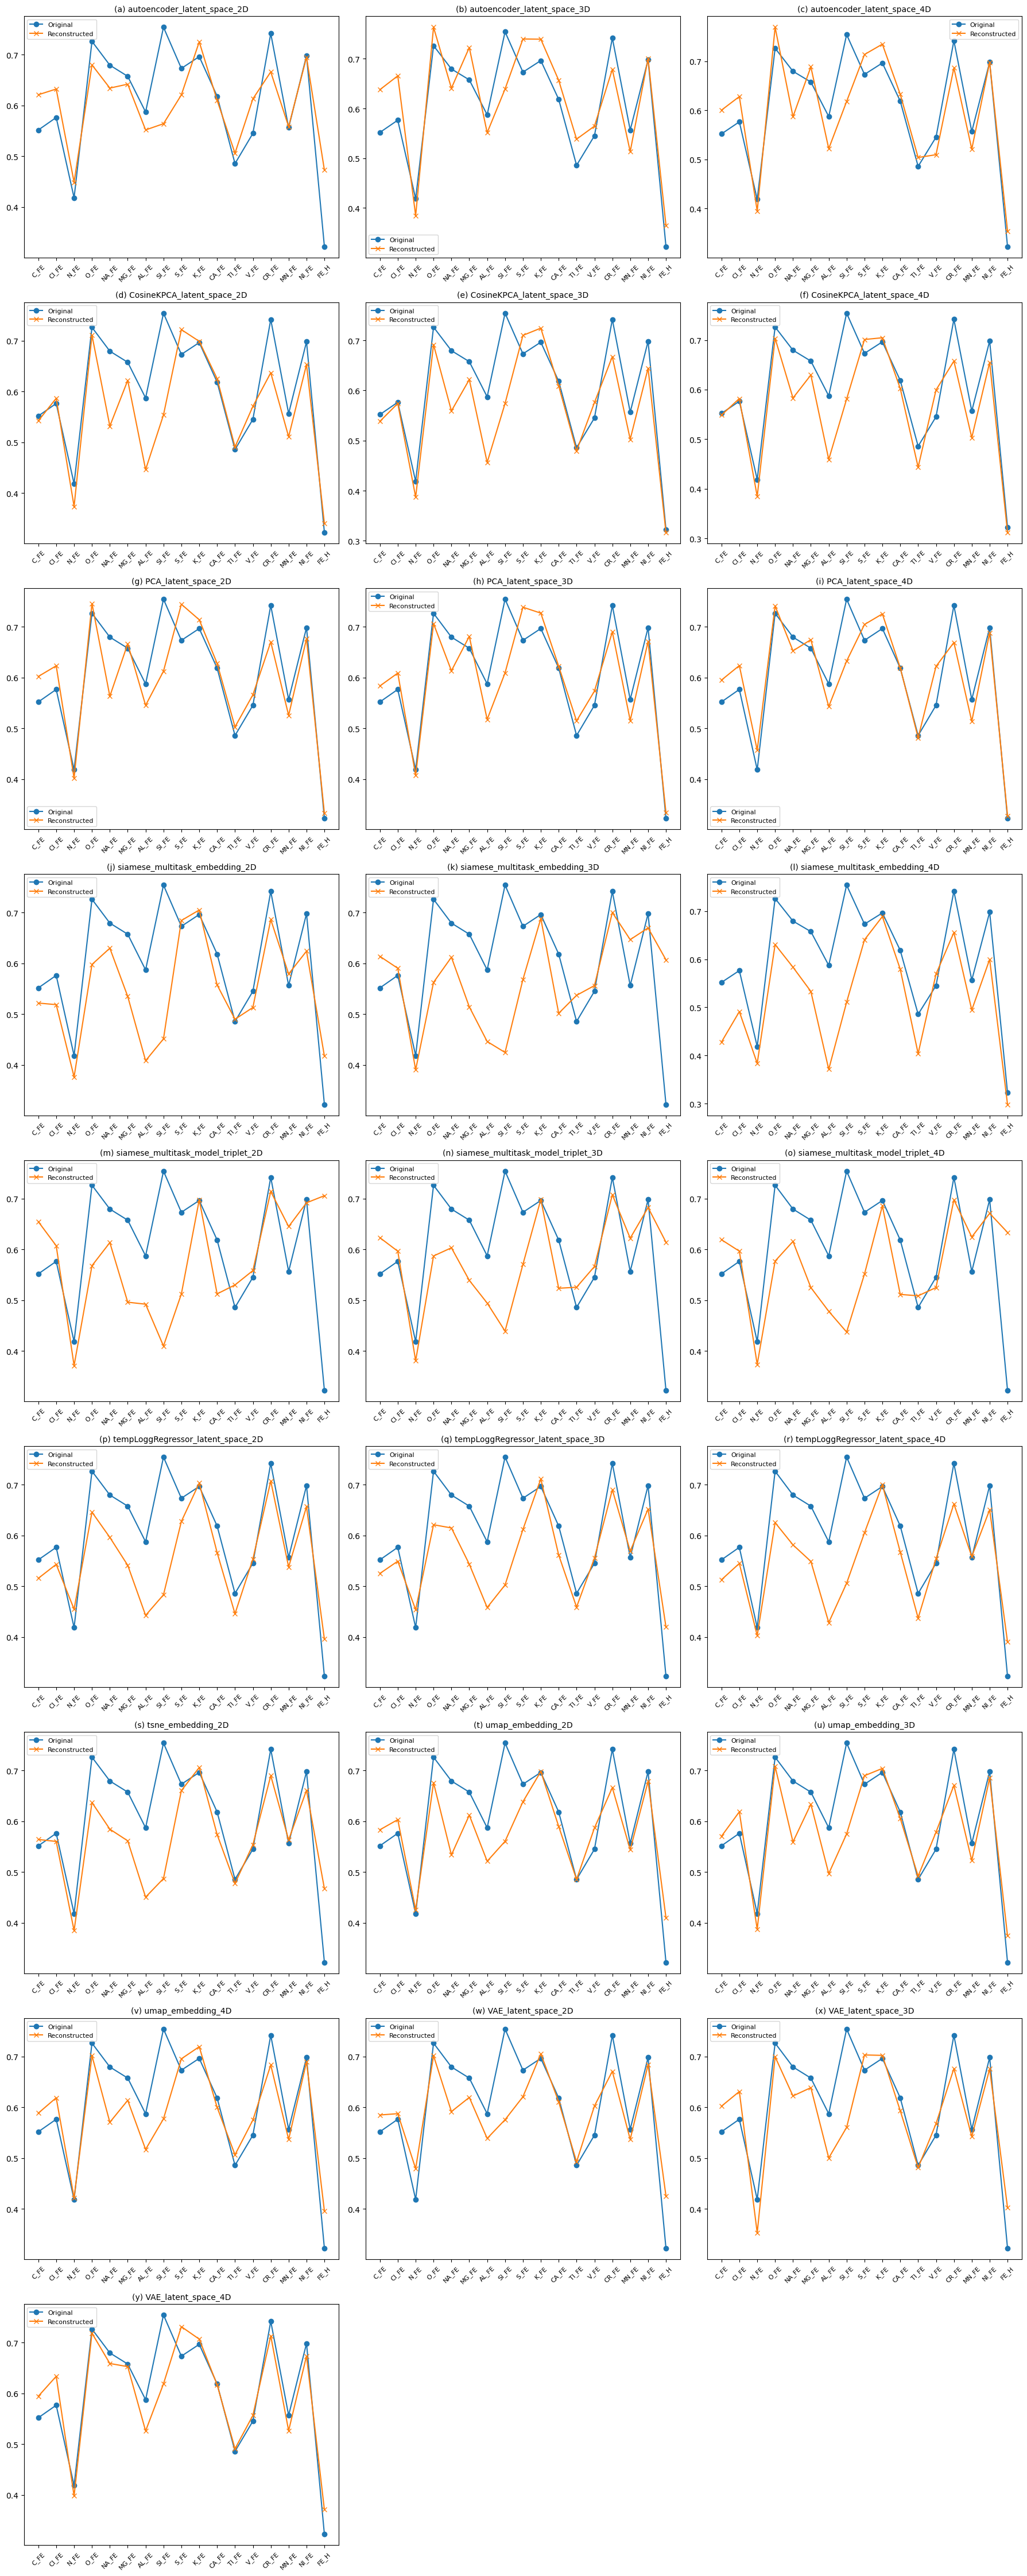

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Choisissez directement l'apogee_id de l'étoile à comparer
chosen_id = "2M15200738+0156288"  # Remplacez par l'ID souhaité
print(f"\nComparing reconstructions for apogee_id={chosen_id}")

# Récupérer l'abondance originale pour cette étoile depuis abundance_full
original_row = abundance_full[abundance_full["apogee_id"] == chosen_id]
if original_row.empty:
    print("Original data not found for chosen star.")
else:
    original_abundance = original_row[col_names].values.flatten()

# Préparer la grille de subplots pour chaque méthode
method_names = list(results.keys())
n_methods = len(method_names)
ncols = 3  # par exemple 3 colonnes
nrows = (n_methods + ncols - 1) // ncols  # suffisamment de lignes
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5*nrows))
axes = axes.flatten()
letters = "abcdefghijklmnopqrstuvwxyz"

for idx, m_name in enumerate(method_names):
    ax = axes[idx]

    # On suppose que results[m_name]["merged_df"] est le DataFrame fusionné (apogee_id + latentes + abondances)
    merged_df = results[m_name]["merged_df"]

    # Filtrer le merged_df pour obtenir uniquement les lignes correspondant au test set
    merged_test = merged_df[merged_df["apogee_id"].isin(list(test_ids))].reset_index(drop=True)

    # Chercher la ligne correspondant à chosen_id dans le test set
    match = merged_test[merged_test["apogee_id"] == chosen_id]
    if match.empty:
        ax.text(0.5, 0.5, f"{m_name}\nNot found in test set", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # L'indice dans le test set (la position dans merged_test)
    test_row_index = match.index[0]

    # Récupérer la reconstruction correspondante dans all_preds (on suppose que l'ordre de all_preds correspond à merged_test)
    recon = results[m_name]["all_preds"][test_row_index]

    # Plot : comparer l'abondance originale et la reconstruction
    ax.plot(range(len(col_names)), original_abundance, marker='o', label="Original")
    ax.plot(range(len(col_names)), recon, marker='x', label="Reconstructed")
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    subplot_label = f"({letters[idx]})" if idx < len(letters) else ""
    ax.set_title(f"{subplot_label} {m_name}", fontsize=10)
    ax.legend(fontsize=8)

# Masquer les subplots inutilisés
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [12]:
import numpy as np
import torch
from torch.utils.data import DataLoader

def compute_train_mse_for_method(m_name, results_dict, abundance_df, global_train_idx):
    """
    Rebuild the train dataset for method m_name, run inference,
    and compute the MSE on the training set.
    """
    # 1) Extract the model
    model = results_dict[m_name]["model"]
    model.eval()  # inference mode

    # 2) Extract the merged_df to see how latent data lines up with original indices
    merged_df = results_dict[m_name]["merged_df"]

    # 3) Determine which rows are in the train set for this method
    mask_train = merged_df["index_orig"].isin(global_train_idx).values

    # 4) Extract the latent columns
    latent_cols = [c for c in merged_df.columns if c not in ["apogee_id", "index_orig"]]
    X_latent = merged_df[latent_cols].values.astype(np.float32)

    # 5) Align abundance data in the same order, then slice for train
    Y_abund = abundance_df.iloc[merged_df["index_orig"].values].values.astype(np.float32)

    X_train = X_latent[mask_train]
    Y_train = Y_abund[mask_train]

    # 6) Create the train dataset and loader
    train_dataset = InverseProjectionDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=False)

    # 7) Run inference on the train set
    all_preds = []
    all_true = []
    with torch.no_grad():
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_true.append(y_batch.numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # 8) Compute the MSE
    mse_train = np.mean((all_preds - all_true)**2)
    return mse_train

# loop over each method and compute train MSE

for m_name in results.keys():
    mse_train = compute_train_mse_for_method(m_name, results, abundance_data, global_train_idx)
    print(f"{m_name} - Train MSE: {mse_train:.6f}")


NameError: name 'global_train_idx' is not defined

/tmp/ipykernel_85256/160567660.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dist_data, labels=labels, vert=True)


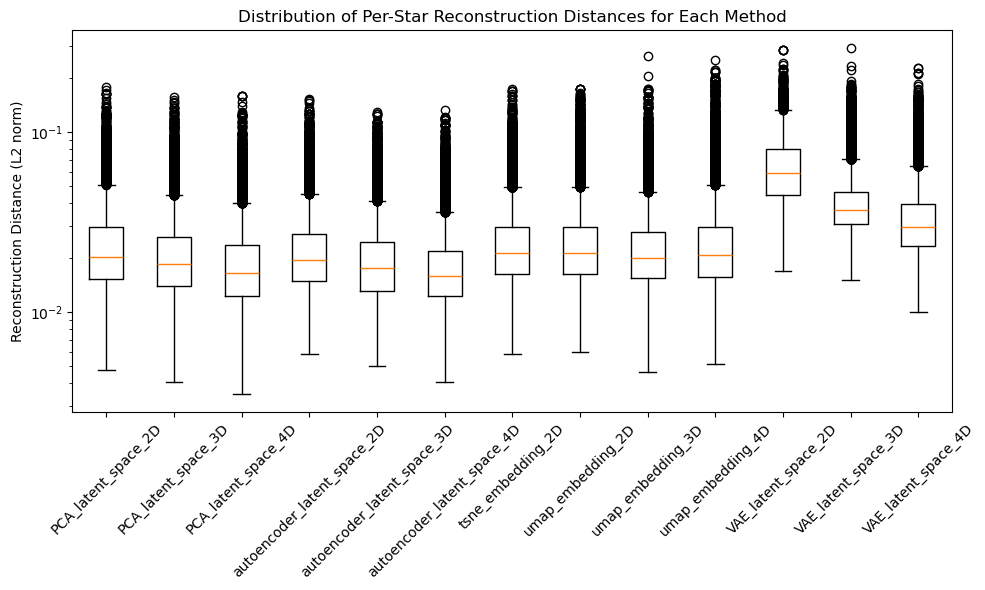

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store per-star errors (distances) for each method
method_starwise_distances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # Compute the L2 distance for each star: sqrt( sum( (pred - true)^2 ) )
    #starwise_dist = np.sqrt(np.sum((all_preds - all_true)**2, axis=1))  # shape [N_test]
    starwise_dist = np.mean(np.abs(all_preds - all_true), axis=1)


    method_starwise_distances[m_name] = starwise_dist

# Boxplot comparing per-star distances across all methods
plt.figure(figsize=(10, 6))
labels = list(method_starwise_distances.keys())
dist_data = [method_starwise_distances[m] for m in labels]
plt.boxplot(dist_data, labels=labels, vert=True)
plt.xticks(rotation=45)
plt.semilogy()
plt.ylabel("Reconstruction Distance (L2 norm)")
plt.title("Distribution of Per-Star Reconstruction Distances for Each Method")
plt.tight_layout()
plt.show()


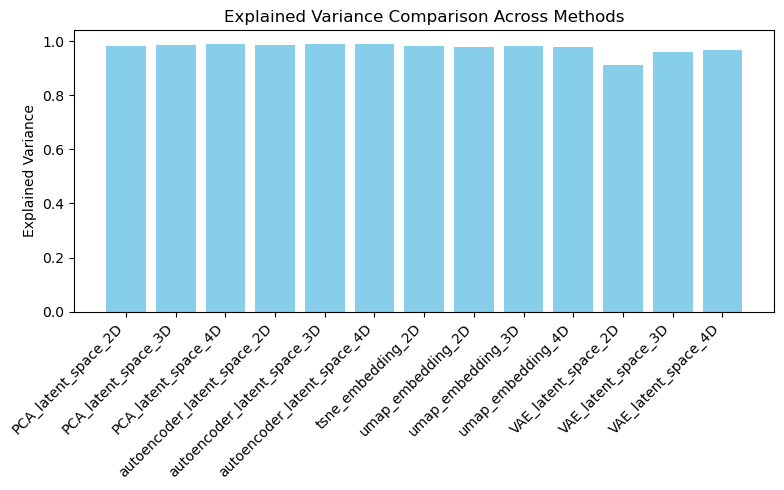

In [58]:
method_explained_variances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # If it's already in the dictionary:
    if "explained_variance" in data_dict:
        ev = data_dict["explained_variance"]
    else:
        # Calculate it if not stored
        cov_matrix = np.cov(all_true, rowvar=False)
        total_variance = np.trace(cov_matrix)
        mse_global = np.mean((all_preds - all_true)**2)
        explained_variance = 1 - (mse_global / total_variance)

    method_explained_variances[m_name] = ev

# Plot a bar chart of explained variance for each method
plt.figure(figsize=(8, 5))
labels = list(method_explained_variances.keys())
ev_values = [method_explained_variances[m] for m in labels]
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.semilogy()
plt.title("Explained Variance Comparison Across Methods")
plt.tight_layout()
plt.show()


In [7]:
# ---------------------------
# 5) LOOP OVER PROJECTION FILES
# ---------------------------
# Example: you might have these files:
projection_files = [
    "siamese_multitask_embedding_2D.csv",
     "siamese_multitask_embedding_3D.csv",
     "siamese_multitask_embedding_4D.csv"
]
results = {}

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    method_path = os.path.join("output_dataset", proj_file)
    df_latent = pd.read_csv(method_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    latent_cols = [c for c in df_latent.columns if c != "apogee_id"]
    input_dim = len(latent_cols)

    print(f"\n=== Training reconstructor for {method_name} (dim={input_dim}) ===")
    out = train_and_evaluate(
        latent_df=df_latent,
        abundance_df=abundance_data,
        apogee_ids=original_data["apogee_id"],
        method_name=method_name,
        input_dim=input_dim,
        global_train_idx=global_train_idx,
        global_test_idx=global_test_idx
    )
    results[method_name] = out



=== Training reconstructor for siamese_multitask_embedding_2D (dim=2) ===
[siamese_multitask_embedding_2D] Epoch 10/100, Train Loss = 0.009672, Val Loss = 0.008699
[siamese_multitask_embedding_2D] Epoch 20/100, Train Loss = 0.005074, Val Loss = 0.005027
[siamese_multitask_embedding_2D] Epoch 30/100, Train Loss = 0.004173, Val Loss = 0.004141
[siamese_multitask_embedding_2D] Epoch 40/100, Train Loss = 0.003665, Val Loss = 0.003645
[siamese_multitask_embedding_2D] Epoch 50/100, Train Loss = 0.003437, Val Loss = 0.003432
[siamese_multitask_embedding_2D] Epoch 60/100, Train Loss = 0.003323, Val Loss = 0.003321
[siamese_multitask_embedding_2D] Epoch 70/100, Train Loss = 0.003239, Val Loss = 0.003240
[siamese_multitask_embedding_2D] Epoch 80/100, Train Loss = 0.003190, Val Loss = 0.003191
[siamese_multitask_embedding_2D] Epoch 90/100, Train Loss = 0.003157, Val Loss = 0.003158
[siamese_multitask_embedding_2D] Epoch 100/100, Train Loss = 0.003130, Val Loss = 0.003133
[siamese_multitask_embed


Comparing reconstructions for apogee_id=2M00000943+6254542 (row_index_orig=5)


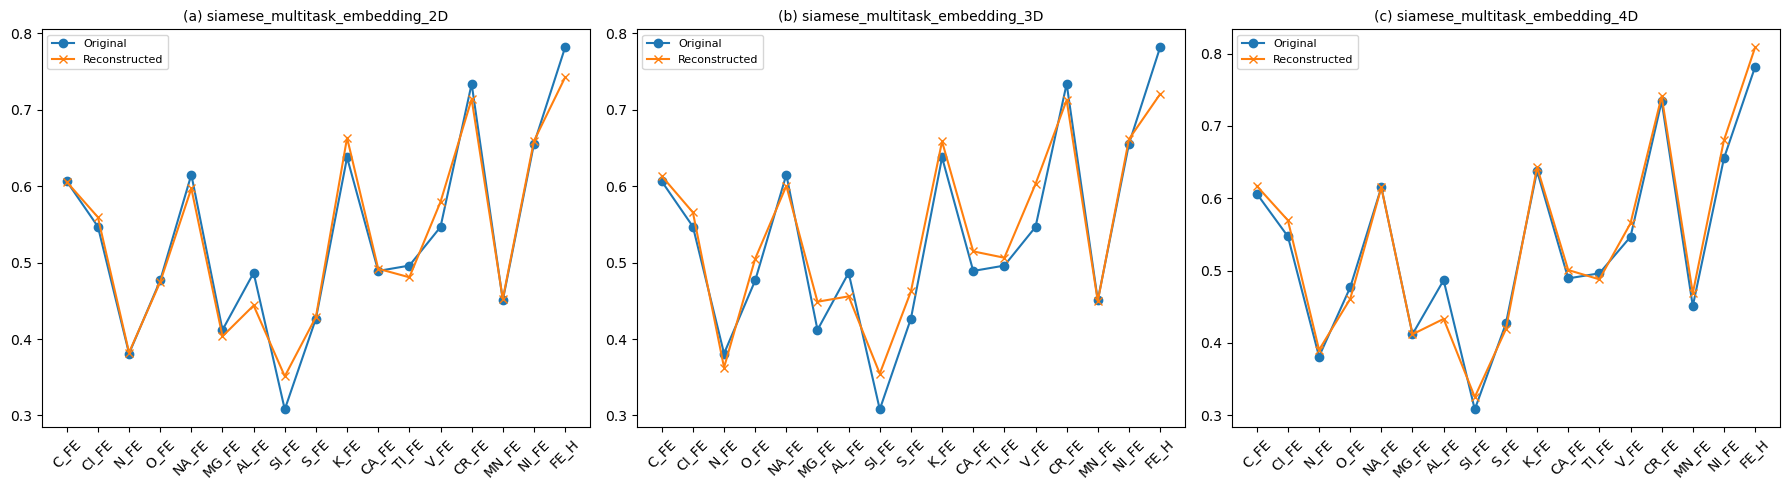

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 7) PICK THE SAME STAR FROM THE TEST SET (CONSISTENT SPLIT) AND PLOT ALL METHODS
# ---------------------------
# 1) Select the first method's test set to guarantee the star is in the test set of at least one method
method_names = list(results.keys())
first_method = method_names[0]

first_method_test_idx = results[first_method]["test_idx"]
row_index_orig = first_method_test_idx[0]  # e.g. pick the first test sample
chosen_id = original_data["apogee_id"].iloc[row_index_orig]
print(f"\nComparing reconstructions for apogee_id={chosen_id} (row_index_orig={row_index_orig})")

# 2) Get the original abundance for this star
original_abundance = abundance_data.iloc[row_index_orig].values

# 3) Prepare a grid of subplots, one per method
n_methods = len(method_names)
ncols = 3  # e.g. 3 columns
nrows = (n_methods + ncols - 1) // ncols  # enough rows to fit all methods
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5*nrows))
axes = axes.flatten()

# (Optional) labels for subplots: (a), (b), (c), ...
letters = "abcdefghijklmnopqrstuvwxyz"

# 4) For each method, plot "Original vs. Reconstruction" in its own subplot
for idx, m_name in enumerate(method_names):
    ax = axes[idx]

    # Retrieve the merged_df to find index_orig
    merged_df = results[m_name]["merged_df"]
    match = merged_df[merged_df["index_orig"] == row_index_orig]
    if match.empty:
        # Star not found in this method's dataset (e.g. if some rows got dropped)
        ax.text(0.5, 0.5, f"{m_name}\nNot found", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Check if the star is in the test set for this method
    test_idx_for_method = results[m_name]["test_idx"]
    idx_pos = np.where(test_idx_for_method == row_index_orig)[0]
    if len(idx_pos) == 0:
        # The star ended up in the train set for this method
        ax.text(0.5, 0.5, f"{m_name}\nIn train set", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Retrieve the reconstruction from all_preds
    pos_in_test = idx_pos[0]
    recon = results[m_name]["all_preds"][pos_in_test]

    # Plot the original abundance (blue line) vs. reconstruction (orange line)
    ax.plot(range(len(col_names)), original_abundance, marker='o', label="Original")
    ax.plot(range(len(col_names)), recon, marker='x', label="Reconstructed")

    # Cosmetic adjustments
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45)
    subplot_label = f"({letters[idx]})" if idx < len(letters) else ""
    ax.set_title(f"{subplot_label} {m_name}", fontsize=10)
    ax.legend(fontsize=8)

# Hide any extra subplots if we have more subplot slots than methods
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


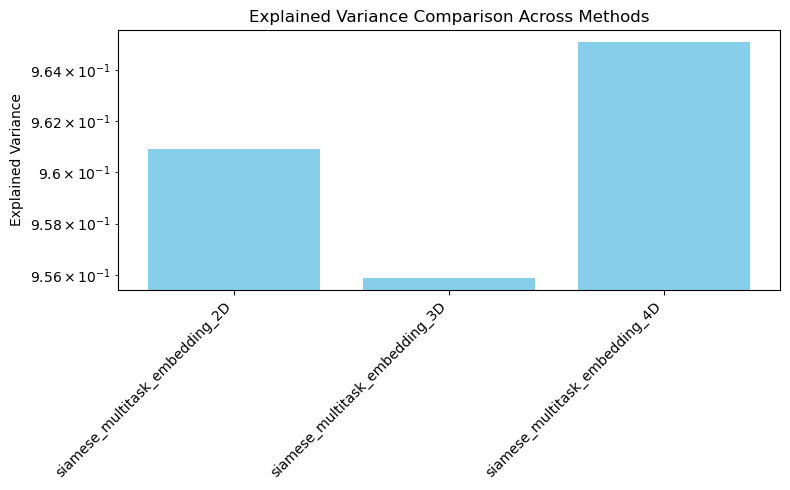

In [10]:
method_explained_variances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # If it's already in the dictionary:
    if "explained_variance" in data_dict:
        ev = data_dict["explained_variance"]
    else:
        # Calculate it if not stored
        cov_matrix = np.cov(all_true, rowvar=False)
        total_variance = np.trace(cov_matrix)
        mse_global = np.mean((all_preds - all_true)**2)
        explained_variance = 1 - (mse_global / total_variance)

    method_explained_variances[m_name] = ev

# Plot a bar chart of explained variance for each method
plt.figure(figsize=(8, 5))
labels = list(method_explained_variances.keys())
ev_values = [method_explained_variances[m] for m in labels]
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.semilogy()
plt.title("Explained Variance Comparison Across Methods")
plt.tight_layout()
plt.show()
